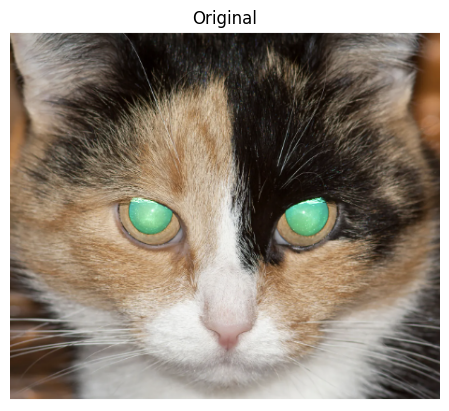

In [1]:
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import torch

img = Image.open("cat.png").convert("RGB")

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

image = transform(img)

plt.imshow(img)
plt.title("Original")
plt.axis("off")
plt.show()

In [2]:
image = image.unsqueeze(0)
image.shape

torch.Size([1, 3, 224, 224])

In [3]:
import torch.nn as nn

conv = nn.Conv2d(
    in_channels=3,
    out_channels=32,
    kernel_size=3,
    padding=1
)

In [4]:
feature_maps = conv(image)
feature_maps.shape

torch.Size([1, 32, 224, 224])

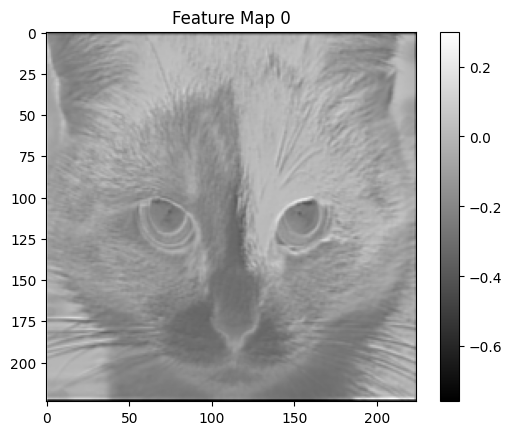

In [5]:
plt.imshow(feature_maps[0,0].detach().numpy(), cmap="gray")
plt.title("Feature Map 0")
plt.colorbar()
plt.show()

In [6]:
feature_maps[0,0].shape

torch.Size([224, 224])

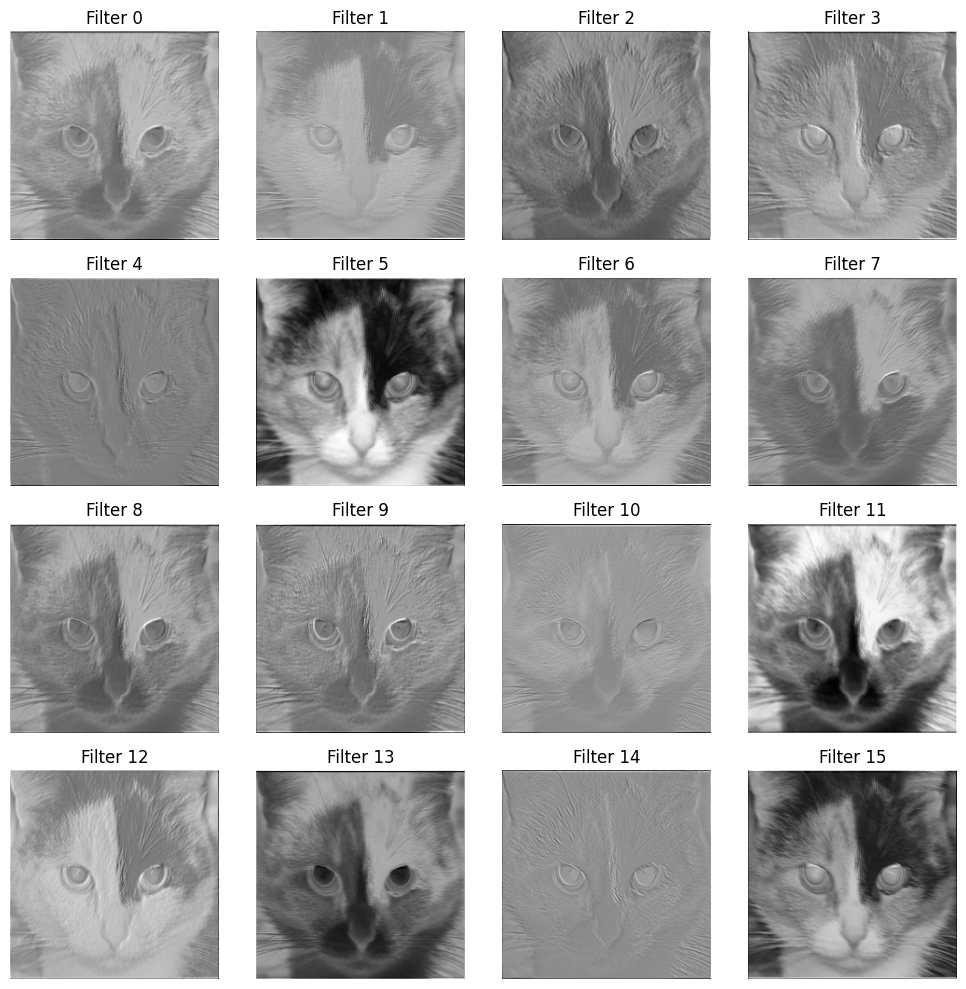

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(10,10))

for i, ax in enumerate(axes.flat):
    ax.imshow(feature_maps[0, i].detach().numpy(), cmap="gray")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Why do the feature maps look weird?
Because these filters are random.
The network hasn’t learned anything yet.
Training changes these numbers from random values into useful detectors.

In [8]:
conv.weight.shape

torch.Size([32, 3, 3, 3])

In [10]:
print(conv.weight[0].shape)
print(conv.weight[0])

torch.Size([3, 3, 3])
tensor([[[-0.1311, -0.0256,  0.1642],
         [-0.1236, -0.0904, -0.0400],
         [ 0.1864,  0.0058,  0.1000]],

        [[-0.0185, -0.0212, -0.0032],
         [-0.0276,  0.0391, -0.1569],
         [-0.1204,  0.1230,  0.1417]],

        [[-0.0786, -0.1909, -0.0490],
         [-0.0626, -0.1688,  0.1722],
         [ 0.0031,  0.0322, -0.0329]]], grad_fn=<SelectBackward0>)


In [15]:
import torch
from torchvision.models import resnet18, ResNet18_Weights

# Load pretrained model
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

# We only want inference
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [17]:
from PIL import Image

img = Image.open("cat.png").convert("RGB")
preprocess = weights.transforms()
image = preprocess(img)
image = image.unsqueeze(0)
image.shape

torch.Size([1, 3, 224, 224])

In [18]:
model.conv1

Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)

It has

* 64 learned filters
* each filter is 7×7×3

In [19]:
with torch.no_grad():
    features = model.conv1(image)

features.shape

torch.Size([1, 64, 112, 112])

Why 112?
Because this layer uses `stride=2`

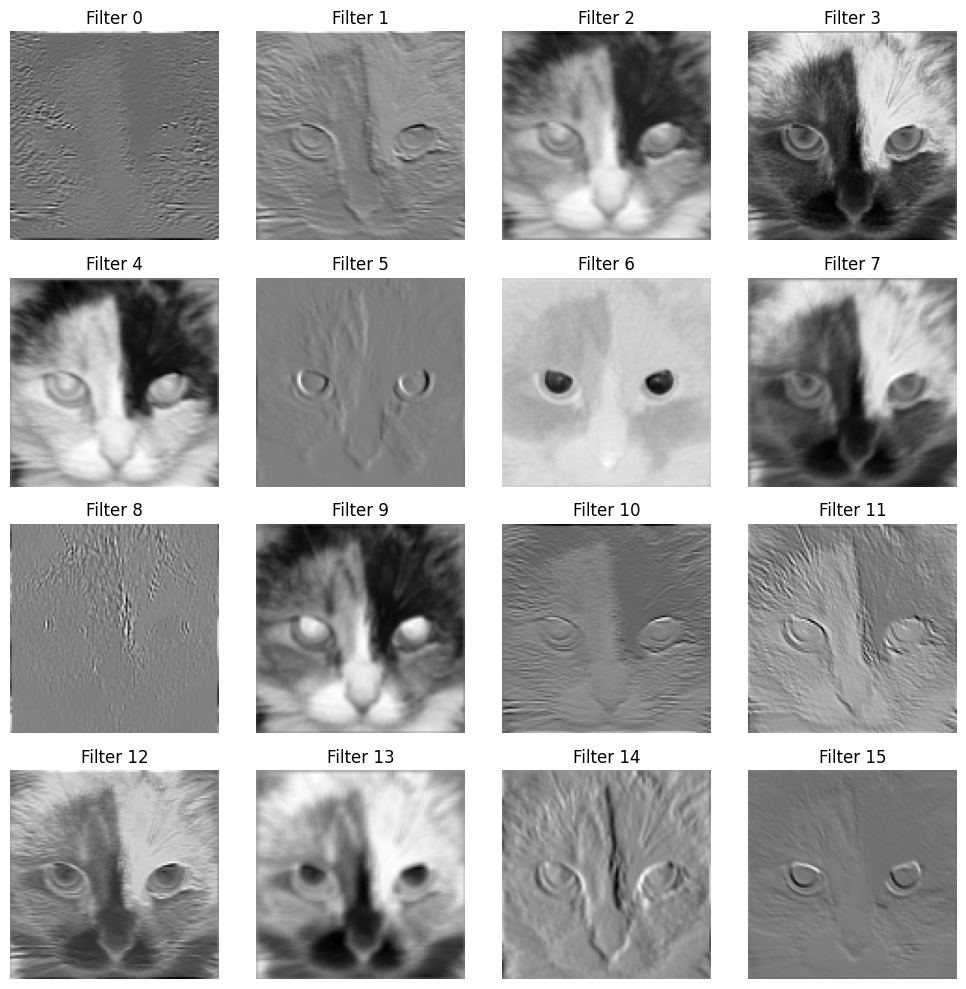

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    feature = features[0, i].cpu().numpy()

    ax.imshow(feature, cmap="gray")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

Bright pixels mean:

“This filter strongly detected its preferred pattern here.”

Dark pixels mean:

“I don’t see my pattern here.”

Each feature map is a “confidence map” for one learned feature.

In [21]:
filters = model.conv1.weight
filters.shape

torch.Size([64, 3, 7, 7])

That means

* 64 filters
* 3 input channels (RGB)
* each is 7×7

In [22]:
print(filters[0])

tensor([[[-1.0419e-02, -6.1356e-03, -1.8098e-03,  7.4841e-02,  5.6615e-02,
           1.7083e-02, -1.2694e-02],
         [ 1.1083e-02,  9.5276e-03, -1.0993e-01, -2.8050e-01, -2.7124e-01,
          -1.2907e-01,  3.7424e-03],
         [-6.9434e-03,  5.9089e-02,  2.9548e-01,  5.8720e-01,  5.1972e-01,
           2.5632e-01,  6.3573e-02],
         [ 3.0505e-02, -6.7018e-02, -2.9841e-01, -4.3868e-01, -2.7085e-01,
          -6.1282e-04,  5.7602e-02],
         [-2.7535e-02,  1.6045e-02,  7.2595e-02, -5.4102e-02, -3.3285e-01,
          -4.2058e-01, -2.5781e-01],
         [ 3.0613e-02,  4.0960e-02,  6.2850e-02,  2.3897e-01,  4.1384e-01,
           3.9359e-01,  1.6606e-01],
         [-1.3736e-02, -3.6746e-03, -2.4084e-02, -6.5877e-02, -1.5070e-01,
          -8.2230e-02, -5.7828e-03]],

        [[-1.1397e-02, -2.6619e-02, -3.4641e-02,  3.6812e-02,  3.2521e-02,
           6.6221e-04, -2.5743e-02],
         [ 4.5687e-02,  3.3603e-02, -1.0453e-01, -3.0885e-01, -3.1253e-01,
          -1.6051e-01, -1.2